In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Iniciando o pipeline de Clusterização...
Dados carregados com sucesso! Total de utilizadores: 10000
Treinando o modelo K-Means...
Treino e segmentação de clusters concluídos!
---Perfil médio dos clusters---
 cluster_id  volume_deposito  saldo_apostas  deposit_velocity  chasing_losses_events  recency  tamanho_cluster
          0             6.96          16.55              0.24                   0.00     0.71             6790
          1            72.93          -2.89              1.92                   1.08     1.07             1584
          2            32.93           0.00              0.89                   0.00   999.00             1244
          3            66.94         553.43              1.06                   0.13     0.40              382


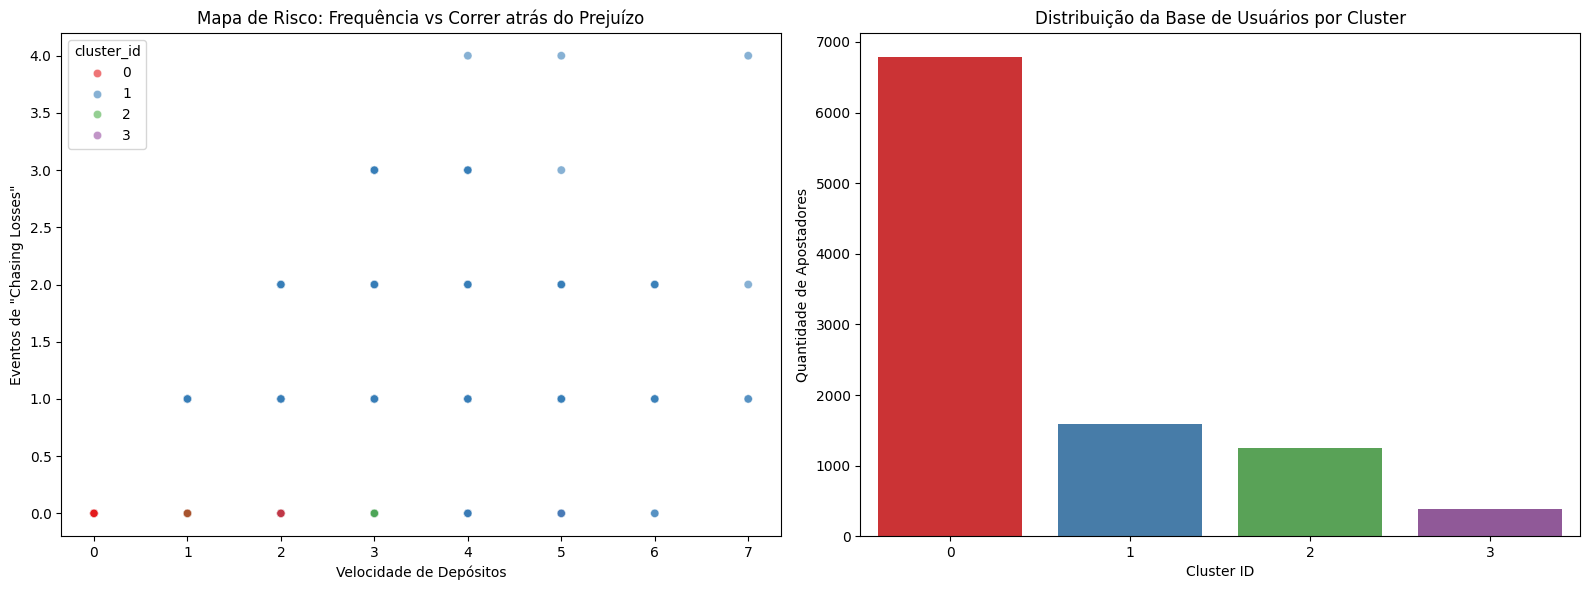

In [3]:
print("Iniciando o pipeline de Clusterização...")

try:
    # Localização da Base de Dados
    current_path = Path(".").resolve()
    db_path = None
    for folder in [current_path] + list(current_path.parents):
        if (folder / "aposta_ganha_dw.db").exists():
            db_path = folder / "aposta_ganha_dw.db"
            break

    if not db_path:
        raise FileNotFoundError("Base de dados não encontrada. Verifique as pastas!")

    # Extração dos Dados 
    conn = sqlite3.connect(str(db_path))
    df = pd.read_sql_query("SELECT * FROM tabela_analytics;", conn)
    conn.close()
    
    print(f"Dados carregados com sucesso! Total de utilizadores: {len(df)}")

    # Pré-processamento e Seleção de Features Estratégicas
    # Para o Jogo Responsável, focamos na impulsividade e no volume financeiro
    features_clustering = ['volume_deposito', 'saldo_apostas', 'deposit_velocity', 'chasing_losses_events', 'recency']
    X_cluster = df[features_clustering].fillna(0)

    # Padronização dos Dados (MUITO IMPORTANTE para o K-Means)
    # Como o K-Means calcula distâncias matemáticas, precisamos deixar todas as 
    # variáveis na mesma escala (ex: não podemos misturar Reais (R$) com Dias)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    print("Treinando o modelo K-Means...")
    
    # Aplicação do Algoritmo K-Means
    # Vamos buscar 4 perfis de comportamento (Recreativo, VIP, Risco de Churn, Compulsivo)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df['cluster_id'] = kmeans.fit_predict(X_scaled)
    print("Treino e segmentação de clusters concluídos!")

    # Perfilamento dos Clusters 
    # Vamos calcular a média de cada variável dentro de cada cluster para entender quem é quem
    cluster_profile = df.groupby('cluster_id')[features_clustering].mean().reset_index()
    cluster_profile['tamanho_cluster'] = df.groupby('cluster_id').size().values
    
    print("---Perfil médio dos clusters---")
    print(cluster_profile.round(2).to_string(index=False))
    

    # Visualização para o Portfólio
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Chasing Losses vs Deposit Velocity
    # Ajuda a identificar o comportamento impulsivo e de risco
    sns.scatterplot(
        data=df, 
        x='deposit_velocity', 
        y='chasing_losses_events', 
        hue='cluster_id', 
        palette='Set1',
        alpha=0.6,
        ax=axes[0]
    )
    axes[0].set_title('Mapa de Risco: Frequência vs Correr atrás do Prejuízo')
    axes[0].set_xlabel('Velocidade de Depósitos')
    axes[0].set_ylabel('Eventos de "Chasing Losses"')

    # Gráfico 2: Tamanho dos Clusters
    sns.barplot(
        data=cluster_profile, 
        x='cluster_id', 
        y='tamanho_cluster', 
        hue='cluster_id',
        palette='Set1',
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title('Distribuição da Base de Usuários por Cluster')
    axes[1].set_xlabel('Cluster ID')
    axes[1].set_ylabel('Quantidade de Apostadores')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Falha na execução: {e}")